# Fine tuning 1

Reentrenamiento de los modelos U-Net, DeepLabV3+ y SegFormer con el Dataset Pascal VOC 2012.

## Importación de paquetes

In [ ]:
import os
import time
import gc
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision.datasets import VOCSegmentation

import albumentations as A                      
#from torchvision import transforms

import cv2
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt

import torch.nn as nn
import torch.nn.functional as F
from tqdm.notebook import tqdm
from torch.utils.tensorboard import SummaryWriter

from torchmetrics.segmentation import MeanIoU
from torchmetrics import JaccardIndex

import segmentation_models_pytorch as smp
from transformers import SegformerConfig, SegformerForSemanticSegmentation

from torch.amp import autocast, GradScaler

from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches


## Configuración global

In [ ]:
CONFIG = {
    "epochs": 60,                                  # N° de pasadas del dataset completo
    "batch": 6,  
    "num_clases": 21,                               # Clases del dataset PascalVoc
    "img_size": 512,                                # Resolución de la imagen de entrada 512x512
    "seed": 42,                                     # Semilla para reproducibilidad
    "data": "../data/",                             # Ruta dataset
    "checkpoint_dir": "../checkpoints/voc/",  # Ruta chechpoint
    "logs_dir": "../logs/voc/",
    "mem_dir": "../memoria/benchmark1/"
}

HIPER_UN = {
    "lr": 1e-4,                                     # Ratio de aprendizaje.
    "weight_decay": 1e-4,                           # Anti-overfitting
}

HIPER_DL = {
    "lr": 1e-4,                                     # Ratio de aprendizaje.
    "weight_decay": 1e-4,                           # Anti-overfitting
}

HIPER_SF = {
    "lr": 1e-4,                                     # Ratio de aprendizaje.
    "weight_decay": 1e-4,                           # Anti-overfitting
}



MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

torch.manual_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])


# Crear carpetas necesarias
#os.makedirs(CONFIG["checkpoint_dir"], exist_ok=True)
#os.makedirs(CONFIG["logs_dir"], exist_ok=True)
#os.makedirs(CONFIG["mem_dir"], exist_ok=True)

In [4]:
#### GPU Info ####
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Usando: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## Transformación para las imágenes de entrenamiento y de validación.

In [4]:
transform_train = A.Compose([
    # Escalado aleatorio
    A.LongestMaxSize(max_size=int(CONFIG["img_size"] * 2.0),
                     interpolation=cv2.INTER_LINEAR),
    A.RandomScale(scale_limit=(-0.5, 0.5), p=1.0,
                  interpolation=cv2.INTER_LINEAR),

    # Padding si la imagen quedó más pequeña que img_size en algún lado.
    # fill_mask=255 para rellenar con la clase "ignorar".
    A.PadIfNeeded(
        min_height=CONFIG["img_size"],
        min_width=CONFIG["img_size"],
        border_mode=cv2.BORDER_CONSTANT,
        fill=0,
        fill_mask=255
    ),

    # Recorte aleatorio al tamaño final
    A.RandomCrop(CONFIG["img_size"], CONFIG["img_size"]),

    # Augmentations geométricas y de color
    A.HorizontalFlip(p=0.5),
    A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1, p=0.5),

    # Normalización ImageNet 
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2()
])



In [5]:
transform_val = A.Compose([
    
    A.LongestMaxSize(max_size=CONFIG["img_size"],
                     interpolation=cv2.INTER_LINEAR),
    A.PadIfNeeded(
        min_height=CONFIG["img_size"],
        min_width=CONFIG["img_size"],
        border_mode=cv2.BORDER_CONSTANT,
        fill=0,
        fill_mask=255
    ),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2()
])

## Dataset PASCAL (Pattern Analysis, Statistical Modelling and Computational Learning) VOC (Visual Object Classes)

In [7]:
class Dataset_VOC(Dataset):
    def __init__(self, root, conjunto="train", transform=None):
        self.dataset = VOCSegmentation(
            root=root, year="2012", image_set=conjunto, download=True
        )
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, indice: int):
        image, mask = self.dataset[indice]
        image = np.array(image)
        mask = np.array(mask)

        # Albumentations exige uint8 para máscaras
        mask = mask.astype(np.uint8)

        if self.transform:
            transformed = self.transform(image=image, mask=mask)
            image = transformed["image"]
            mask = transformed["mask"]

        # Conversión segura a tensor long (independiente de si el transform ya devolvió tensor)
        if not torch.is_tensor(mask):
            mask = torch.from_numpy(mask)
        mask = mask.long()

        return image, mask

Crear/cargar datasets para entrenamiento y validación.

In [7]:
train_data = Dataset_VOC(CONFIG["data"], "train", transform_train)
val_data = Dataset_VOC(CONFIG["data"], "val", transform_val)

Creación de DataLoader para entrenamiento y validación.

In [8]:
train_loader = DataLoader(
    train_data,                                         
    batch_size=CONFIG["batch"],
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_data,
    batch_size=CONFIG["batch"],
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [9]:
print(f"N° imágenes de entrenamiento: {len(train_data)} imágenes | {len(train_loader)} batches")
print(f"N° imágenes de validación: {len(val_data)} imágenes | {len(val_loader)} batches")

N° imágenes de entrenamiento: 1464 imágenes | 244 batches
N° imágenes de validación: 1449 imágenes | 242 batches


En la siguiente celda se definen las clases del dataset Pascal Voc.

- Hay 20 clases de objetos + 1 para el fondo.


In [15]:
VOC_CLASES = [
    "background",
    "aeroplane", "bicycle", "bird", "boat", "bottle", "bus", "car",
    "cat", "chair", "cow", "diningtable", "dog", "horse", "motorbike",
    "person", "pottedplant", "sheep", "sofa", "train", "tvmonitor"
]
"""
0: fondo
1: aeroplano
2: bicicleta
3: pájaro
4: barco
5: botella
6: autobús
7: coche
8: gato
9: silla
10: vaca
11: mesa de comedor
12: perro
13: caballo
14: moto
15: persona
16: planta en maceta
17: ovejas
18: sofá
19: tren
20: monitor de televisión
"""

'\n0: fondo\n1: aeroplano\n2: bicicleta\n3: pájaro\n4: barco\n5: botella\n6: autobús\n7: coche\n8: gato\n9: silla\n10: vaca\n11: mesa de comedor\n12: perro\n13: caballo\n14: moto\n15: persona\n16: planta en maceta\n17: ovejas\n18: sofá\n19: tren\n20: monitor de televisión\n'

In [11]:
COLORMAP = [
    [0,0,0],
    [128,0,0],     [0,128,0],     [128,128,0],
    [0,0,128],     [128,0,128],   [0,128,128],   [128,128,128],
    [64,0,0],      [192,0,0],     [64,128,0],    [192,128,0],
    [64,0,128],    [192,0,128],   [64,128,128],  [192,128,128],
    [0,64,0],      [128,64,0],    [0,192,0],     [128,192,0],
    [0,64,128]
]

Función para convertir la máscara (información de a que clase pertenece cada pixel) en una imágen RGB para poder visualizarla.

In [12]:
def colorear_mascara(mask):
    mask_color = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for cls, color in enumerate(COLORMAP):
        mask_color[mask == cls] = color
    return mask_color


Función para desnormalizar la imágen para poder visualizarla correctamente.

In [13]:
def desnormalizar(tensor):
    mean = torch.tensor(MEAN).view(3,1,1)
    std = torch.tensor(STD).view(3,1,1)
    return (tensor * std + mean).clamp(0,1)

### Visualización de ejemplos

In [14]:
def visualizar_ejemplos(images, masks, n=6):
    
    fig, axes = plt.subplots(2, n, figsize=(4*n, 8))

    for i in range(n):
        img = desnormalizar(images[i]).permute(1,2,0).numpy()
        axes[0,i].imshow(img)
        axes[0,i].set_title("Imagen")
        axes[0,i].axis("off")

        axes[1,i].imshow(colorear_mascara(masks[i].numpy()))
        axes[1,i].set_title("Máscara")
        axes[1,i].axis("off")

    plt.suptitle("Ejemplos Pascal VOC 2012", fontsize=14)
    plt.tight_layout()
    plt.show()


In [ ]:
"""
0: fondo            1: aeroplano                2: bicicleta
3: pájaro           4: barco                    5: botella
6: autobús          7: coche                    8: gato
9: silla            10: vaca                    11: mesa de comedor
12: perro           13: caballo                 14: moto
15: persona         16: planta en maceta        17: ovejas
18: sofá            19: tren                    20: monitor de televisión
"""

'\n0: fondo\n1: aeroplano\n2: bicicleta\n3: pájaro\n4: barco\n5: botella\n6: autobús\n7: coche\n8: gato\n9: silla\n10: vaca\n11: mesa de comedor\n12: perro\n13: caballo\n14: moto\n15: persona\n16: planta en maceta\n17: ovejas\n18: sofá\n19: tren\n20: monitor de televisión\n'

Shape imágenes:  torch.Size([6, 3, 512, 512])
Shape máscaras:  torch.Size([6, 512, 512])
Clases únicas:   tensor([  0,   5,   8,   9,  10,  11,  15,  18,  19,  20, 255])


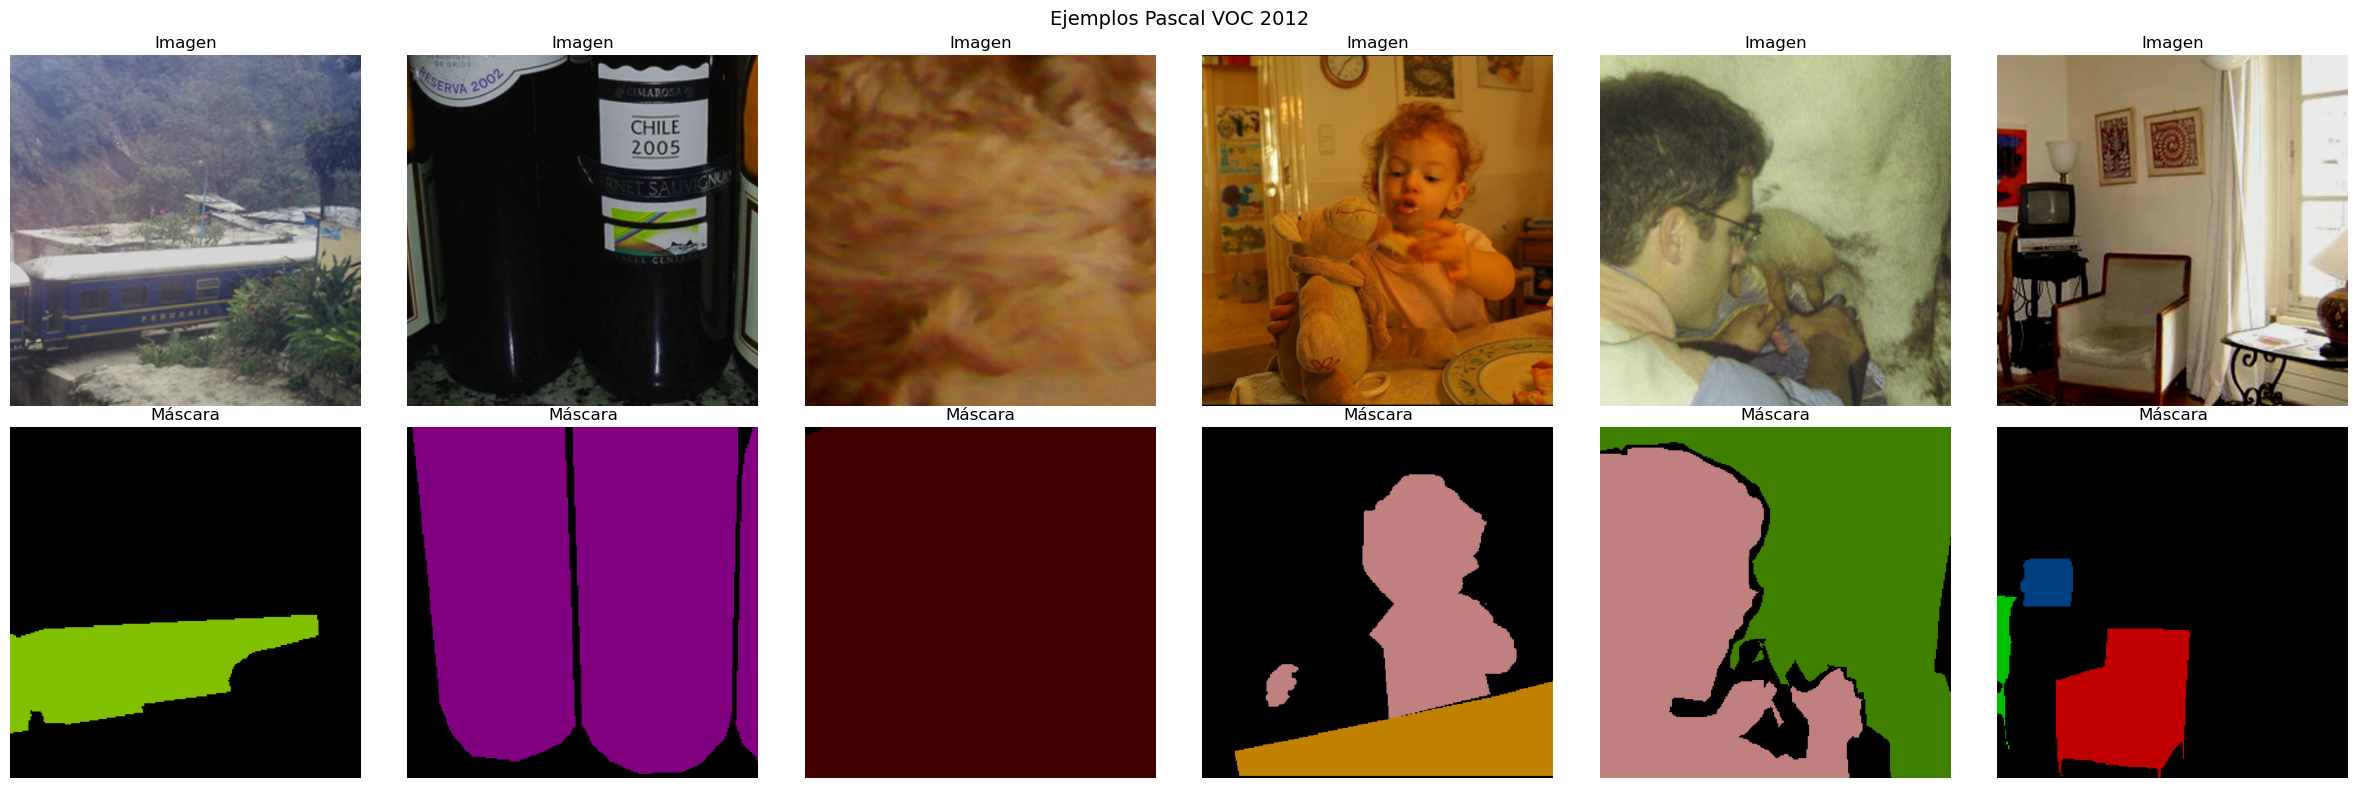

In [15]:
# Verificar shapes
images, masks = next(iter(train_loader))
print(f"Shape imágenes:  {images.shape}")
print(f"Shape máscaras:  {masks.shape}")
print(f"Clases únicas:   {masks.unique()}")

# Visualizar
visualizar_ejemplos(images, masks)



## Definir modelos

In [16]:
# ── U-Net ──────────────────────────────────────
unet = smp.Unet(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=21
)

def forward_unet(model, images):
    out = model(images)
    if out.shape[-2:] != images.shape[-2:]:
        out = F.interpolate(out, size=images.shape[-2:], 
                           mode="bilinear", align_corners=False)
    return out

print(f"** U-Net -> N° parámetros: {sum(p.numel() for p in unet.parameters())/1e6:.1f}M")
print("\n** Modelo U-Net cargado")

** U-Net -> N° parámetros: 32.5M

** Modelo U-Net cargado


In [17]:
# ── DeepLabV3+ ──────────────────────────────────
deeplabv3plus = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,
    classes=CONFIG["num_clases"]
)

def forward_deeplabv3plus(model, images):
    out = model(images)
    if out.shape[-2:] != images.shape[-2:]:
        out = F.interpolate(out, size=images.shape[-2:],
                           mode="bilinear", align_corners=False)
    return out

print(f"\n** DeepLabV3Plus -> N° parámetros: {sum(p.numel() for p in deeplabv3plus.parameters())/1e6:.1f}M")
print("\n** Modelo DeepLabV3Plus cargado")


** DeepLabV3Plus -> N° parámetros: 26.7M

** Modelo DeepLabV3Plus cargado


In [18]:
# ── SegFormer ──────────────────────────────────
segformer = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/mit-b2",
    num_labels=CONFIG["num_clases"],
    ignore_mismatched_sizes=True
)

def forward_segformer(model, images):
    outputs = model(pixel_values=images)
    return F.interpolate(
        outputs.logits,
        size=images.shape[-2:],
        mode="bilinear",
        align_corners=False
    )

print(f"\n\n\n** SegFormer -> N° parámetros: {sum(p.numel() for p in segformer.parameters())/1e6:.1f}M")
print("\n** Modelo SegFormer cargado")

[transformers] You passed `num_labels=21` which is incompatible to the `id2label` map of length `1000`.


Loading weights:   0%|          | 0/364 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b2
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.weight                             | UNEXPECTED | 
classifier.bias                               | UNEXPECTED | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading fr




** SegFormer -> N° parámetros: 27.4M

** Modelo SegFormer cargado


### Definición de la función de pérdida

In [19]:
class perdidaDiceCE(nn.Module):
    def __init__(self):
        super().__init__()
        self.dice = smp.losses.DiceLoss(
            mode="multiclass",
            ignore_index=255
        )
        self.ce = nn.CrossEntropyLoss(ignore_index=255)

    def forward(self, pred, obj):
        return 0.5 * self.dice(pred, obj) + 0.5 * self.ce(pred, obj)

loss_fn = perdidaDiceCE()
print("-> Función de pérdida definida")

-> Función de pérdida definida


## Bucle de entrenamiento

In [ ]:
def entrenar_modelo(modelo, nombre, forward_fn, hiper):

    ############################
    # Reset de semilla
    torch.manual_seed(CONFIG["seed"])
    np.random.seed(CONFIG["seed"])
    ############################

    modelo = modelo.to(device)

    writer  = SummaryWriter(log_dir=f"../logs/voc/{nombre}")

    miou_fn = JaccardIndex(
        task="multiclass",
        num_classes=CONFIG["num_clases"],
        ignore_index=255,
        average="macro"
    ).to(device)
    
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, modelo.parameters()),
        lr=hiper["lr"],
        weight_decay=hiper["weight_decay"]
    )
    """ 
    # Actualización de la tasa de aprendizaje.##############
    """
    scheduler_step_per_iter=False
    if (nombre == "unet"):
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=CONFIG["epochs"], eta_min=1e-6
        )
        scheduler_step_per_iter = False

    elif(nombre == "deeplabv3plus"):
        scheduler = torch.optim.lr_scheduler.PolynomialLR(
            optimizer,
            total_iters=CONFIG["epochs"] * len(train_loader),
            power=0.9
        )
        scheduler_step_per_iter = True

    else:
        scheduler = torch.optim.lr_scheduler.PolynomialLR(
            optimizer,
            total_iters=CONFIG["epochs"] * len(train_loader),
            power=1.0
        )
        scheduler_step_per_iter = True
    
    """ 
    ########################################################
    """

    scaler = GradScaler("cuda")
    
    historial = {
        "loss_train": [],
        "miou_val": []
    }

    tiempo_entrenamiento = 0.0
    mejor_miou = 0.0
    
    for epoch in range(CONFIG["epochs"]):

        # Aquí empieza el entrenamiento de cada epoch
        inicio_epoch = time.time()
        # -- Train ---------------------------
        modelo.train()
        loss_total = 0

        pbar = tqdm(
            train_loader,
            desc=f"[{nombre}] Epoch {epoch+1}/{CONFIG['epochs']}",
            leave=False
        )

        for images, masks in pbar:
            images = images.to(device, non_blocking=True)
            masks = masks.long().to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with autocast("cuda"):
                preds = forward_fn(modelo, images)
                loss = loss_fn(preds, masks)


            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(modelo.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

            if scheduler_step_per_iter:
                scheduler.step()

            loss_total += loss.item()
            pbar.set_postfix(loss=f"{loss.item():.4f}")


        loss_media = loss_total / len(train_loader)

        

        # -- Validación ---------------------------
        modelo.eval()
        miou_fn.reset()

        with torch.no_grad():
            for images, masks in val_loader:
                images = images.to(device)
                masks  = masks.long().to(device)
                preds  = forward_fn(modelo, images).argmax(dim=1)
                miou_fn.update(preds, masks)


        miou_val = miou_fn.compute().item()   
            

        tiempo_epoch = (time.time() - inicio_epoch)/60 # tiempo en min del entrenamiento de cada epochs.
        # -- Sumar tiempo epoch ---------------------------
        tiempo_entrenamiento += tiempo_epoch    # Sumo tiempo de epoch.

        # -- Guardar historial ---------------------------
        historial["loss_train"].append(loss_media)
        historial["miou_val"].append(miou_val)
        
        # -- TensorBoard ---------------------------
        writer.add_scalar("Loss/train", loss_media, epoch)
        writer.add_scalar("mIoU/val", miou_val, epoch)
        writer.add_scalar("LR", optimizer.param_groups[0]["lr"], epoch)
        writer.add_scalar("Tiempo/epoch", tiempo_epoch, epoch)

        print(f"[{nombre}] Epoch {epoch+1:02d} | Loss: {loss_media:.4f} | mIoU: {miou_val*100:.2f}% | Tiempo: {tiempo_epoch:.2f} min")

        # -- Guardar mejor modelo ---------------------------
        if miou_val > mejor_miou:
            mejor_miou = miou_val
            torch.save({
                "epoch": epoch,
                "modelo": modelo.state_dict(),
                "optimizer": optimizer.state_dict(),
                "scheduler": scheduler.state_dict(),
                "mejor_miou": mejor_miou,
                "historial": historial
            },
            f"{CONFIG['checkpoint_dir']}{nombre}_b1_checkpoint.pth"
            )
            print(f"  -- Guardado modelo {nombre} con mIoU = {mejor_miou*100:.2f}%")

        if not scheduler_step_per_iter:
            scheduler.step()   # disminuye learning rate.
    
    writer.close()
    
    print(f"\n\n-->>    {nombre} completado | Mejor mIoU: {mejor_miou*100:.2f}% | Tiempo total de entrenamiento: {tiempo_entrenamiento:.2f} min   <<--")
    
    #--- Libero memoria VRAM ------------------
    modelo.cpu()
    del modelo
    del optimizer
    del scheduler
    del miou_fn
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
    #--------------------------------
    
    return mejor_miou, historial, tiempo_entrenamiento

## Entrenamiento modelos

In [21]:
# Entrenar U-net
miou_unet, hist_unet, tiempo_unet = entrenar_modelo(
    unet, "unet", forward_unet, HIPER_UN
)

[unet] Epoch 1/60:   0%|          | 0/244 [00:00<?, ?it/s]

[unet] Epoch 01 | Loss: 1.1828 | mIoU: 11.97% | Tiempo: 1.57 min
  -- Guardado modelo unet con mIoU = 11.97%


[unet] Epoch 2/60:   0%|          | 0/244 [00:00<?, ?it/s]

[unet] Epoch 02 | Loss: 0.8495 | mIoU: 14.18% | Tiempo: 1.58 min
  -- Guardado modelo unet con mIoU = 14.18%


[unet] Epoch 3/60:   0%|          | 0/244 [00:00<?, ?it/s]

...

[unet] Epoch 58 | Loss: 0.1695 | mIoU: 59.34% | Tiempo: 1.60 min


[unet] Epoch 59/60:   0%|          | 0/244 [00:00<?, ?it/s]

[unet] Epoch 59 | Loss: 0.1741 | mIoU: 59.30% | Tiempo: 1.61 min


[unet] Epoch 60/60:   0%|          | 0/244 [00:00<?, ?it/s]

[unet] Epoch 60 | Loss: 0.1801 | mIoU: 59.15% | Tiempo: 1.60 min


-->>    unet completado | Mejor mIoU: 59.90% | Tiempo total de entrenamiento: 95.61 min   <<--


In [22]:
#Entrenar DeepLabV3Plus
miou_deeplabv3plus, hist_deeplabv3plus, tiempo_deeplabv3plus = entrenar_modelo(
    deeplabv3plus, "deeplabv3plus", forward_deeplabv3plus, HIPER_DL
)

[deeplabv3plus] Epoch 1/60:   0%|          | 0/244 [00:00<?, ?it/s]

[deeplabv3plus] Epoch 01 | Loss: 0.9474 | mIoU: 24.08% | Tiempo: 1.36 min
  -- Guardado modelo deeplabv3plus con mIoU = 24.08%


[deeplabv3plus] Epoch 2/60:   0%|          | 0/244 [00:00<?, ?it/s]

[deeplabv3plus] Epoch 02 | Loss: 0.6253 | mIoU: 39.28% | Tiempo: 1.32 min
  -- Guardado modelo deeplabv3plus con mIoU = 39.28%


[deeplabv3plus] Epoch 3/60:   0%|          | 0/244 [00:00<?, ?it/s]

...

[deeplabv3plus] Epoch 58 | Loss: 0.0660 | mIoU: 70.00% | Tiempo: 1.32 min
  -- Guardado modelo deeplabv3plus con mIoU = 70.00%


[deeplabv3plus] Epoch 59/60:   0%|          | 0/244 [00:00<?, ?it/s]

[deeplabv3plus] Epoch 59 | Loss: 0.0654 | mIoU: 70.01% | Tiempo: 1.32 min
  -- Guardado modelo deeplabv3plus con mIoU = 70.01%


[deeplabv3plus] Epoch 60/60:   0%|          | 0/244 [00:00<?, ?it/s]

[deeplabv3plus] Epoch 60 | Loss: 0.0613 | mIoU: 70.14% | Tiempo: 1.32 min
  -- Guardado modelo deeplabv3plus con mIoU = 70.14%


-->>    deeplabv3plus completado | Mejor mIoU: 70.14% | Tiempo total de entrenamiento: 79.02 min   <<--


In [23]:
# Entrenar SegFormer
miou_segformer, hist_segformer, tiempo_segformer = entrenar_modelo(
    segformer, "segformer", forward_segformer, HIPER_SF
)

[segformer] Epoch 1/60:   0%|          | 0/244 [00:00<?, ?it/s]

[segformer] Epoch 01 | Loss: 0.6081 | mIoU: 58.44% | Tiempo: 2.35 min
  -- Guardado modelo segformer con mIoU = 58.44%


[segformer] Epoch 2/60:   0%|          | 0/244 [00:00<?, ?it/s]

[segformer] Epoch 02 | Loss: 0.3163 | mIoU: 66.69% | Tiempo: 2.30 min
  -- Guardado modelo segformer con mIoU = 66.69%


[segformer] Epoch 3/60:   0%|          | 0/244 [00:00<?, ?it/s]

...

[segformer] Epoch 58 | Loss: 0.0278 | mIoU: 79.84% | Tiempo: 2.30 min


[segformer] Epoch 59/60:   0%|          | 0/244 [00:00<?, ?it/s]

[segformer] Epoch 59 | Loss: 0.0289 | mIoU: 79.94% | Tiempo: 2.31 min


[segformer] Epoch 60/60:   0%|          | 0/244 [00:00<?, ?it/s]

[segformer] Epoch 60 | Loss: 0.0246 | mIoU: 80.06% | Tiempo: 2.31 min


-->>    segformer completado | Mejor mIoU: 80.06% | Tiempo total de entrenamiento: 137.69 min   <<--


## Visualizacion datos de entrenamiento.

In [27]:
"""
ALMACENAR MEJOR mIoU ENTRENAMIENTO.
"""
res_mejor=[]
mejor_unet={"Modelo":"U-Net", 
            "Mejor mIoU(%) entrenamiento":round(miou_unet*100,2), 
            "Tiempo entrenamiento (min)":round(tiempo_unet,2)}
res_mejor.append(mejor_unet)

mejor_deeplabv3plus={"Modelo":"DeepLabV3plus",
                     "Mejor mIoU(%) entrenamiento":round(miou_deeplabv3plus*100,2),
                     "Tiempo entrenamiento (min)":round(tiempo_deeplabv3plus,2)}
res_mejor.append(mejor_deeplabv3plus)

mejor_segformer={"Modelo":"SegFormer",
                 "Mejor mIoU(%) entrenamiento":round(miou_segformer*100,2),
                 "Tiempo entrenamiento (min)":round(tiempo_segformer,2)}
res_mejor.append(mejor_segformer)


t = pd.DataFrame(res_mejor)
display(t)

,Modelo,Mejor mIoU(%) entrenamiento,Tiempo entrenamiento (min)
0,U-Net,59.90,95.61
1,DeepLabV3plus,70.14,79.02
2,SegFormer,80.06,137.69


Guardo los resultados del entrenamiento en un archivo csv

In [28]:
t.to_csv(CONFIG["mem_dir"]+"resultados_b1_entrenamiento.csv")

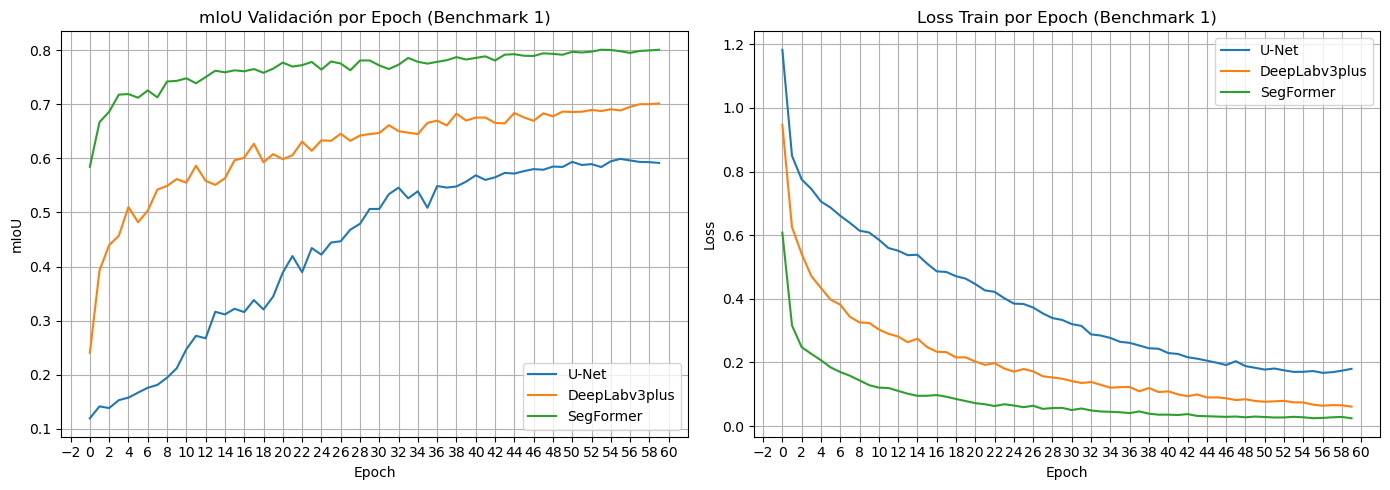

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curvas mIoU
for nombre, hist in [
    ("U-Net", hist_unet),
    ("DeepLabv3plus", hist_deeplabv3plus),
    ("SegFormer", hist_segformer)
]:
    axes[0].plot(hist["miou_val"], label=nombre)

axes[0].set_title("mIoU Validación por Epoch (Voc)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("mIoU")
axes[0].legend()
axes[0].xaxis.set_major_locator(plt.MultipleLocator(2))
axes[0].grid(True)

# Curvas Loss
for nombre, hist in [
    ("U-Net", hist_unet),
    ("DeepLabv3plus", hist_deeplabv3plus),
    ("SegFormer", hist_segformer)
]:
    axes[1].plot(hist["loss_train"], label=nombre)

axes[1].set_title("Loss Train por Epoch (Voc)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].xaxis.set_major_locator(plt.MultipleLocator(2))
axes[1].grid(True)

plt.tight_layout()
plt.savefig("../memoria/benchmark1/curvas_entrenamiento_b1.png", dpi=150)
plt.show()